In [ ]:
#Name: Shreetu Shrestha
#2417729

def MCP_Neurons_AND(X1, X2, T):
    """
    MCP Neuron for AND operation
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        # Apply threshold
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate: {result}")

Output of AND gate: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    MCP Neuron for OR operation
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        # Apply threshold
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate: {result_or}")

Output of OR gate: [0, 1, 1, 1]


**Question - 1: List out all the limitations of MCP - Neurons.**

1. Limitations of MCP Neurons
Can only solve linearly separable problems
Cannot solve XOR problem
Uses fixed weights and threshold (no learning)
No adaptability (not trainable like modern models)
Limited to simple binary classification

**Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.**

2. XOR cannot be solved with a single MCP neuron because XOR is not linearly separable.

In [3]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


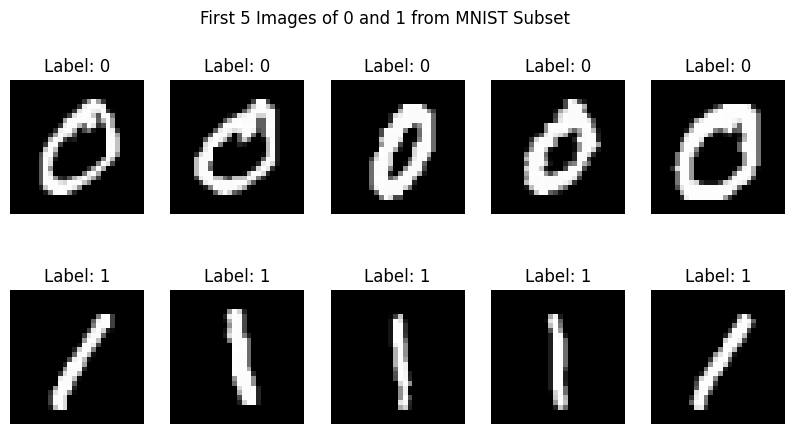

In [4]:
import matplotlib.pyplot as plt
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
    # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
    # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

**Question - 1: What does the shape of X represent?**

X.shape represents= number of images and features (28×28 pixels flattened)

Epoch 10, Accuracy: 99.34%
Epoch 20, Accuracy: 99.54%
Epoch 30, Accuracy: 99.63%
Epoch 40, Accuracy: 99.66%
Epoch 50, Accuracy: 99.68%
Epoch 60, Accuracy: 99.70%
Epoch 70, Accuracy: 99.72%
Epoch 80, Accuracy: 99.72%
Epoch 90, Accuracy: 99.72%
Epoch 100, Accuracy: 99.74%
The Final Accuracy is:  99.73943939992104
Final Accuracy: 0.9974


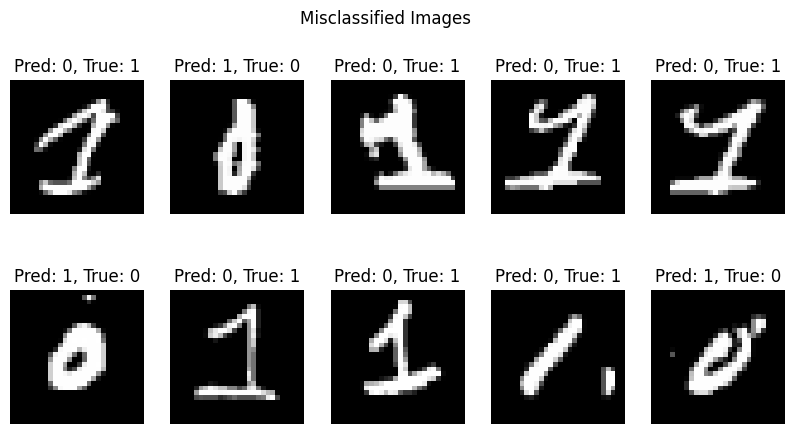

In [7]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

import numpy as np
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############ # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0);  # np.where(condition, value_if_true, value_if_false)
    return y_pred_all

import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)
    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        correct_count = 0
        y_pred_all = decision_function(X, weights, bias)

        for i in range(X.shape[0]):
            X_sample = X[i]
            y_pred_single = y_pred_all[i]
            y_true = y[i]

            error = y_true - y_pred_single

            if error !=0:
                weights = weights + learning_rate * error * X_sample
                bias = bias + learning_rate * error
            else:
                correct_count +=1

        if (epoch + 1) % 10 ==0:
            epoch_accuracy = (correct_count/ X.shape[0]) * 100
            print(f"Epoch {epoch+1}, Accuracy: {epoch_accuracy:.2f}%")

    y_pred_final = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_final == y) / len(y) * 100

    return weights, bias, accuracy

    # After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

**Question - 3: What does the weights array represent in this context?**

Each weight corresponds to a pixel importance


**Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?**

Simplicity and Ensures uniform starting point
Downside: may slow learning slightly, but perceptron still works

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

The expression np.dot(X[i], weights) + bias calculates the weighted sum of input features plus a bias term. It represents how strongly the input image activates the neuron and is used to decide whether the output should be classified as 0 or 1.

**Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?**

When the prediction is incorrect, the perceptron updates its weights and bias to reduce future errors. The weights are adjusted based on the input values and learning rate, and the bias is also modified. This helps the model gradually learn the correct decision boundary.

**Question - 7:Why is the final accuracy important, and what do you expect it to be?**

Final accuracy measures how well the perceptron performs on the dataset. It is important because it shows the effectiveness of the model in classifying inputs correctly. For digits 0 vs 1, the accuracy is expected to be very high, often close to 100%, since the data is linearly separable.

**Question - 8:What does misclassified idx store, and how is it used in this code?**

misclassified_idx stores the indices of all data points where the predicted labels do not match the true labels. It is used to identify and visualize the incorrectly classified images, helping us understand where the model is making mistakes.

**Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?**

If the output says "All images were correctly classified!", it means the model achieved perfect accuracy on the dataset. This indicates that the perceptron successfully learned a decision boundary that correctly separates all input samples.

Final Accuracy: 0.9857716161984678


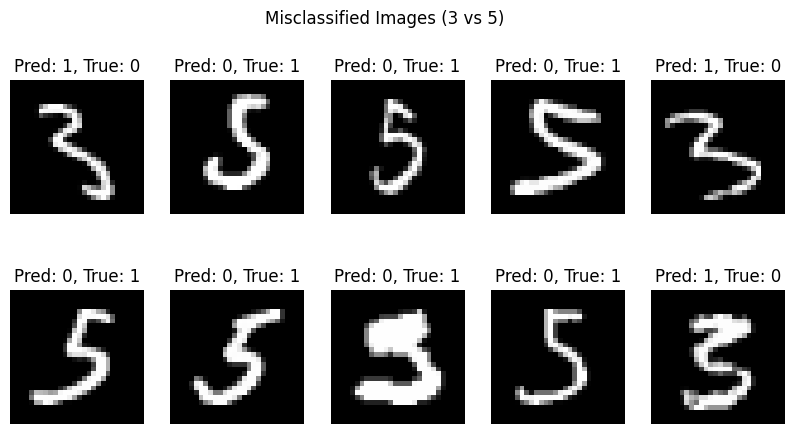

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

# Features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# FIX HERE
y = np.where(y == 3, 0, 1)
# Initialize
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

# Decision function
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

# Training function
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            error = y[i] - y_pred

            # Update weights properly
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

            if error == 0:
                correct += 1

        accuracy = correct / len(X)

    return weights, bias, accuracy

# Train model
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

# Predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

# Visualization
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")